## Anomaly detection in manufactured parts using ResNET50

This project notebook aims to develop a Computer Vision program based in Deep Learning, able to detect any anomalies in manufactured parts, by making use of **pre-trained Convolutional Neural Networks**, specifically ResNET50. 

The dataset used for training and testing is the MVTEC-ad, [available publicly via Kaggle](https://www.kaggle.com/datasets/ipythonx/mvtec-ad), focusing exclusively on the cable category. 

### 0. Load libraries and dependencies

In [10]:
import torch
import torch.nn as nn
from torchvision.models import wide_resnet50_2, Wide_ResNet50_2_Weights
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score
from sklearn.preprocessing import StandardScaler
from PIL import Image
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# For experiment tracking
import mlflow
import mlflow.sklearn

# For environment variables
import os
from dotenv import load_dotenv

# For data loading
import kagglehub

### 1. Load MVTEC-ad data from Kaggle
MVTEC anomaly detection dataset

Paul Bergmann, Michael Fauser, David Sattlegger, and Carsten Steger,
"A Comprehensive Real-World Dataset for Unsupervised Anomaly Detection",
IEEE Conference on Computer Vision and Pattern Recognition, 2019

In [ ]:
# Dataset from Kaggle
path = kagglehub.dataset_download("ipythonx/mvtec-ad")
print("Path to dataset files:", path)

print("Folders found:", os.listdir(path))

 14%|█▎        | 687M/4.91G [01:16<08:05, 9.38MB/s]  


KeyboardInterrupt: 

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

### 2. Set-up experiment tracking in Databricks MLFlow

In [14]:
load_dotenv()
DATABRICKS_TOKEN = os.getenv('DATABRICKS_TOKEN')
DATABRICKS_HOST = os.getenv('DATABRICKS_HOST')
MLFLOW_TRACKING_URI = os.getenv('MLFLOW_TRACKING_URI')
MLFLOW_EXPERIMENT_ID = os.getenv('EXP_ID_QUALITY')

os.environ['DATABRICKS_TOKEN'] = DATABRICKS_TOKEN
os.environ['DATABRICKS_HOST'] = DATABRICKS_HOST
os.environ['MLFLOW_TRACKING_URI'] = MLFLOW_TRACKING_URI
os.environ['MLFLOW_EXPERIMENT_ID'] = MLFLOW_EXPERIMENT_ID

mlflow.set_experiment(os.getenv('EXPERIMENT_NAME'));

### 3. Feature engineering & latent space mapping functions

In [ ]:
# Load pretrained model and feature extractor
def get_feature_extractor():
    #Wide ResNet 50 with pretrained weigths on ImageNet
    model = wide_resnet50_2(weights='Wide_ResNet50_2_Weights.IMAGENET1K_V1')
    #model = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)

    # Extract until 'avgpool' layer of the vector of the latent space of 2048 dimensions
    modules = list(model.children())[:-1]
    feature_extractor = nn.Sequential(*modules).to(device)
    feature_extractor.eval()
    return feature_extractor

# Wide Resnet 50 required transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


def extract_latent_features(data_loader, model):
    all_features = []
    all_labels = []

    print(f"Starting feature extraction on {device}...")

    with torch.no_grad(): # Deactivate gradients for memory efficiency
        for batch_idx, (images, labels) in enumerate(data_loader):
            images = images.to(device)

            # Forward pass through the model to get features
            # Output: [batch_size, 2048, 1, 1]
            features = model(images)

            # Flatten tensor to [batch_size, 2048]
            features = features.view(features.size(0), -1)

            # Move to CPU and convert to Numpy for SVM/PCA
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())

            print(f"Processing batch {batch_idx}...")

    # Concatenate batches in single matrix of size [N, 2048]
    return np.vstack(all_features), np.concatenate(all_labels)

In [ ]:
# Custom Dataset for MVTec
class MVTecDataset(Dataset):
    def __init__(self, root_dir, category, transform=None, is_train=True):
        self.root_dir = root_dir
        self.category = category
        self.transform = transform
        self.is_train = is_train

        # Define path based on train/test
        subfolder = 'train' if is_train else 'test'
        self.dir_path = os.path.join(root_dir, category, subfolder)

        self.image_files = []
        self.labels = [] # 1 for normal, -1 for anomaly

        # Scan folders
        for label_name in os.listdir(self.dir_path):
            label_dir = os.path.join(self.dir_path, label_name)
            if not os.path.isdir(label_dir): continue

            for img_name in os.listdir(label_dir):
                self.image_files.append(os.path.join(label_dir, img_name))
                self.labels.append(1 if label_name == 'good' else -1)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

### 4. Feature Extraction & Data Standardization

In [ ]:
# Training and testing datasets
categoria = "cable"
train_data = MVTecDataset(root_dir=path, category=categoria, transform=transform, is_train=True)
test_data = MVTecDataset(root_dir=path, category=categoria, transform=transform, is_train=False)

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

#TRAINING
# Feature extraction from training set
extractor = get_feature_extractor()
train_features, train_labels = extract_latent_features(train_loader, extractor)
print(f"Feature extraction completed. Shape of the matrix: {train_features.shape}")

#Standardization
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)

Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth


100%|██████████| 132M/132M [00:01<00:00, 114MB/s]


Iniciando extracción en cuda...
Procesando batch 0...
Procesando batch 1...
Procesando batch 2...
Procesando batch 3...
Procesando batch 4...
Procesando batch 5...
Procesando batch 6...
Extracción completada. Forma de la matriz: (224, 2048)


### 5. Model training, evaluation, and experiment tracking

Dimensiones reducidas de 2048 a: 132
Iniciando extracción en cuda...
Procesando batch 0...
Procesando batch 1...
Procesando batch 2...
Procesando batch 3...
Procesando batch 4...

RESULTADOS 
Testing accuraccy: 66.67%
F1-score: 0.6753246753246753
Recall: 0.5217391304347826


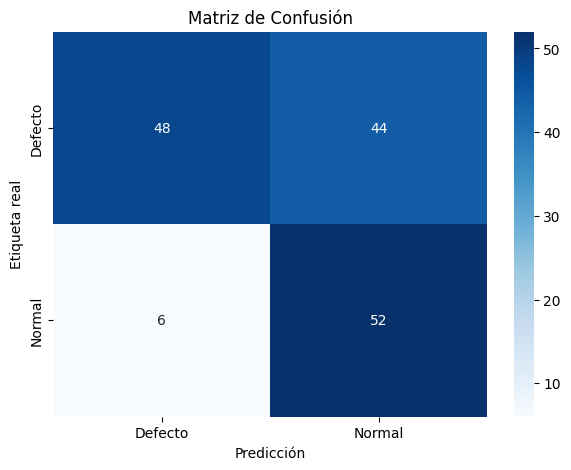

🏃 View run EfficientNet_PCA_95_NU_0.01_STANDARIZED_gamma_scale at: https://dbc-91223b91-1e6c.cloud.databricks.com/ml/experiments/435341972481074/runs/8404a4e5245a41ca8326c8b78c034d21
🧪 View experiment at: https://dbc-91223b91-1e6c.cloud.databricks.com/ml/experiments/435341972481074


In [ ]:
with mlflow.start_run():

  params = {
        "model_type": "WideResNET_50",
        "pca_variance": 0.95,
        "svm_nu": 0.01,
        "svm_gamma": "scale",
        "category": "cable"
    }
  mlflow.log_params(params)

  # Dimensionality Reduction (PCA) from 2048 to a number that maintains a defined variance
  pca = PCA(n_components=params["pca_variance"])
  train_features_pca = pca.fit_transform(train_features_scaled)
  print(f"Dimensions reduced from 2048 to: {train_features_pca.shape[1]}")

  # One-class SVM
  # nu=0.05 assumes 5% of the data is noise
  oc_svm = svm.OneClassSVM(kernel='rbf', gamma=params['svm_gamma'], nu=params['svm_nu'])
  oc_svm.fit(train_features_pca)

  # Evaluation with test set
  test_features, test_labels_extracted = extract_latent_features(test_loader, extractor)
  test_features_scaled = scaler.transform(test_features)
  test_features_pca = pca.transform(test_features_scaled)

  # Predictions: 1 for normal, -1 for defect
  predictions = oc_svm.predict(test_features_pca)

  # Results
  true_labels = test_data.labels
  true_labels = np.array(true_labels)

  acc = accuracy_score(true_labels, predictions)
  f1 = f1_score(true_labels, predictions)
  recall = recall_score(true_labels, predictions, pos_label=-1)

  mlflow.log_metric("final_accuracy", acc)
  mlflow.log_metric("f1_score", f1)
  mlflow.log_metric("defect_recall", recall)

  print(f"\nRESULTS: ")
  print(f"Testing accuraccy: {acc * 100:.2f}%")
  print(f"F1-score: {f1}")
  print(f"Recall: {recall}")

  cm = confusion_matrix(true_labels, predictions)
  fig, ax = plt.subplots(figsize=(7, 5))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=['Defect', 'Normal'],
              yticklabels=['Defect', 'Normal'], ax=ax)
  ax.set_xlabel('Prediction')
  ax.set_ylabel('Real label')
  ax.set_title('Confusion matrix')
  plt.show()

  # Save confusion matrix
  mlflow.log_figure(fig, "plots/confusion_matrix.png")
  plt.close(fig)

mlflow.end_run()